# Import libraries

In [12]:
# Importing Libraries
# Basic Libraries
import numpy as np
import pandas as pd

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# ML Utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Feature Selection
from sklearn.feature_selection import chi2

# ML Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB

# Metrics
from sklearn.metrics import accuracy_score, confusion_matrix


# Load The DataSet

In [13]:
# Loading The Dataset
df = pd.read_csv('/content/IMDB Dataset.csv')


In [14]:
# Print The Shape Of Data
df.shape


(50000, 2)

In [15]:
# Print The Data
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [16]:
# Print The Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


# Preprocess The Dataset
1. Missing Values

In [17]:
# Checking For Missing Values
df.isnull().sum()

,0
review,0
sentiment,0


2. Duplicated Values

In [18]:
# Checking For Duplicated Values
print('Number Of Duplicated Values In The Dataset: ', df.duplicated().sum())

Number Of Duplicated Values In The Dataset:  418


In [19]:
# drop  Duplicated Values
df = df.drop_duplicates()
print('Number Of Duplicated Values In The Dataset after drop: ', df.duplicated().sum())

Number Of Duplicated Values In The Dataset after drop:  0


3. Class Imbalance

In [20]:
# Check class imbalance
print(df['sentiment'].value_counts())
print("\nPercentage:\n", df['sentiment'].value_counts(normalize=True) * 100)


sentiment
positive    24884
negative    24698
Name: count, dtype: int64

Percentage:
 sentiment
positive    50.187568
negative    49.812432
Name: proportion, dtype: float64


TF -IDF

In [21]:

vectorizer = TfidfVectorizer(max_features=3000, stop_words='english')
X_tfidf = vectorizer.fit_transform(df['review'])

df_tfidf = pd.DataFrame(X_tfidf.toarray(), columns=vectorizer.get_feature_names_out())
df_tfidf['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

df_tfidf = df_tfidf.dropna()

X = df_tfidf.drop('sentiment', axis=1)
y = df_tfidf['sentiment']


Chi-Square Feature Importance

In [22]:

chi_scores, p_values = chi2(X, y)

chi2_results = pd.DataFrame({
    'feature': X.columns,
    'chi2_score': chi_scores,
    'p_value': p_values
})

chi2_results = chi2_results.sort_values(by='chi2_score', ascending=False)
chi2_results.head(20)


,feature,chi2_score,p_value
952,fairy,3.493275,0.061619
223,bad,3.356006,0.066960
1045,flynn,3.263206,0.070850
2897,waste,2.868435,0.090333
898,excellent,2.521037,0.112337
2974,worst,2.504976,0.113487
857,enjoyed,2.286419,0.130511
348,brooks,2.221555,0.136096
2231,romantic,2.105255,0.146794
1917,passion,2.089010,0.148362


Top Positive vs Top Negative Words

In [23]:

# Extracting TF-IDF words
feature_names = vectorizer.get_feature_names_out()

# Separate data by sentiment
pos_tfidf = df_tfidf[df_tfidf["sentiment"] == 1].drop("sentiment", axis=1)
neg_tfidf = df_tfidf[df_tfidf["sentiment"] == 0].drop("sentiment", axis=1)

# Total TF-IDF per word within each category
pos_scores = np.array(pos_tfidf.sum(axis=0)).flatten()
neg_scores = np.array(neg_tfidf.sum(axis=0)).flatten()

# Word order
top_pos_idx = pos_scores.argsort()[::-1][:20]   # Top 20 positive words
top_neg_idx = neg_scores.argsort()[::-1][:20]   # Top 20 negative words

top_positive_words = [(feature_names[i], pos_scores[i]) for i in top_pos_idx]
top_negative_words = [(feature_names[i], neg_scores[i]) for i in top_neg_idx]

print("Top Positive Words:")
print(top_positive_words)

print("------------------------------------")

print("\nTop Negative Words:")
print(top_negative_words)


Top Positive Words:
[('br', np.float64(3078.507522805172)), ('movie', np.float64(1579.3008032414361)), ('film', np.float64(1359.8676682461842)), ('like', np.float64(761.1070826623311)), ('just', np.float64(709.9008874496242)), ('good', np.float64(672.2042890935594)), ('story', np.float64(573.1179932736811)), ('really', np.float64(567.4273388744067)), ('time', np.float64(563.2038813990437)), ('great', np.float64(518.7237908215004)), ('bad', np.float64(500.6991393410259)), ('people', np.float64(470.9309010502964)), ('don', np.float64(460.81935752153026)), ('movies', np.float64(455.13492395918195)), ('watch', np.float64(436.6546336926703)), ('think', np.float64(416.58048730162864)), ('seen', np.float64(409.24300386630694)), ('make', np.float64(407.91041259103133)), ('love', np.float64(404.38030093970116)), ('characters', np.float64(402.94674501235755))]
------------------------------------

Top Negative Words:
[('br', np.float64(3029.2188962813593)), ('movie', np.float64(1587.246119776819

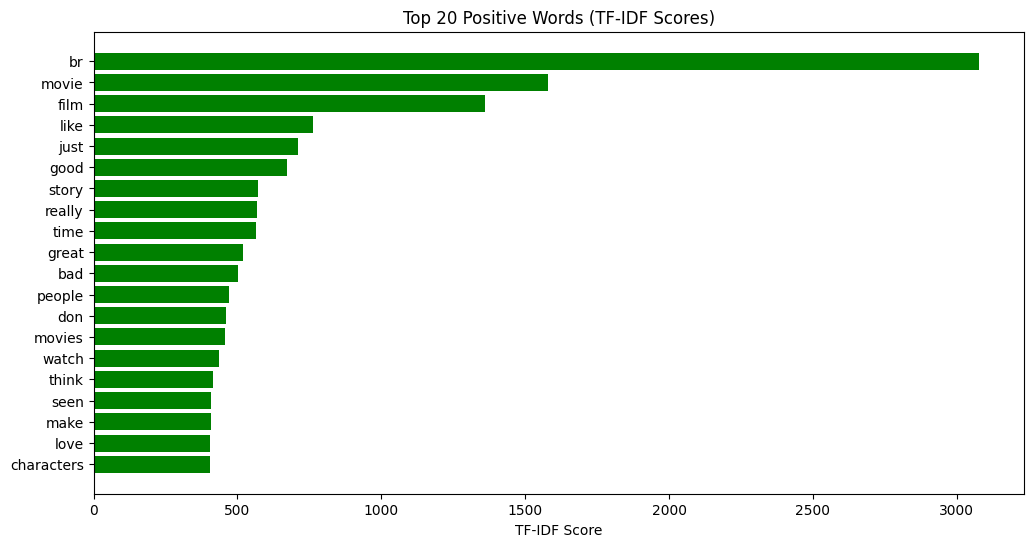

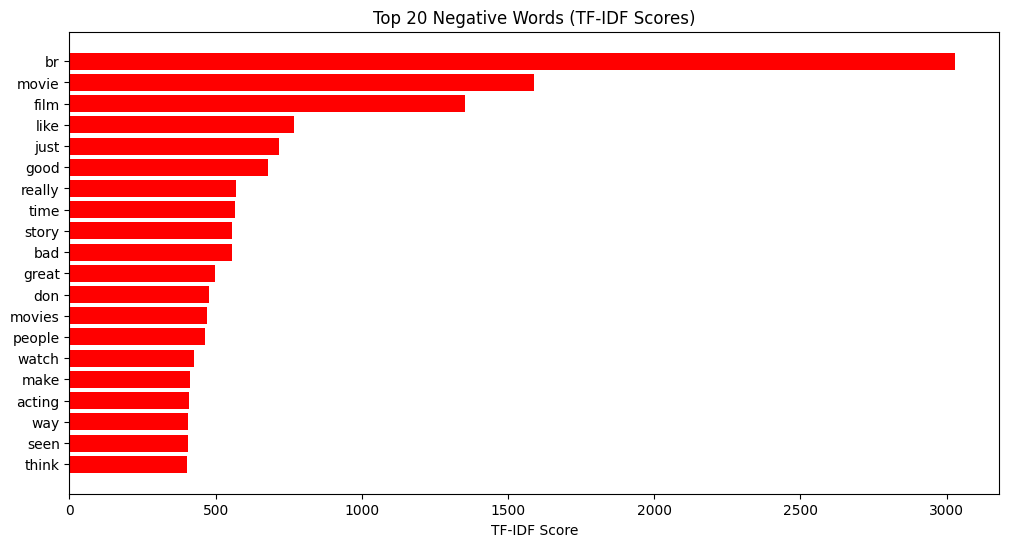

In [24]:

# Convert to separate lists
pos_words = [w for w, s in top_positive_words]
pos_values = [s for w, s in top_positive_words]

neg_words = [w for w, s in top_negative_words]
neg_values = [s for w, s in top_negative_words]

plt.figure(figsize=(12, 6))
plt.barh(pos_words[::-1], pos_values[::-1], color='green')
plt.title("Top 20 Positive Words (TF-IDF Scores)")
plt.xlabel("TF-IDF Score")
plt.show()

plt.figure(figsize=(12, 6))
plt.barh(neg_words[::-1], neg_values[::-1], color='red')
plt.title("Top 20 Negative Words (TF-IDF Scores)")
plt.xlabel("TF-IDF Score")
plt.show()


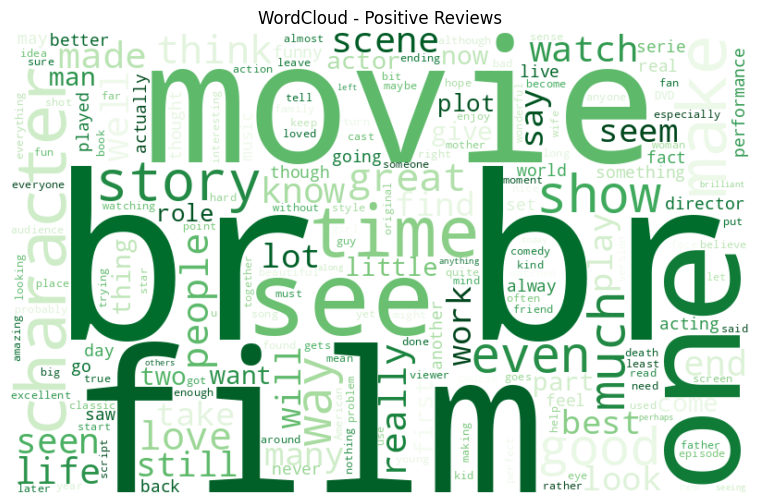

In [25]:

# Positive texts
pos_text = " ".join(df[df["sentiment"] == "positive"]["review"].astype(str))



# WordCloud Positive
wc_pos = WordCloud(width=800, height=500, background_color='white', colormap='Greens').generate(pos_text)
plt.figure(figsize=(10, 6))
plt.imshow(wc_pos, interpolation='bilinear')
plt.axis("off")
plt.title("WordCloud - Positive Reviews")
plt.show()



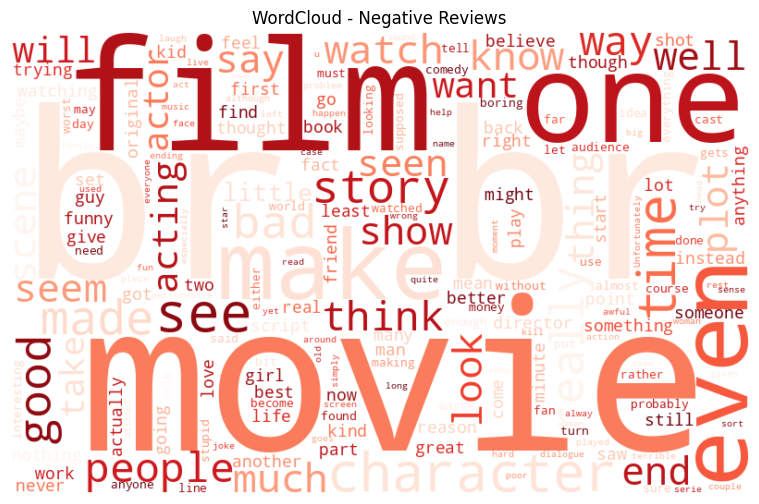

In [26]:
#  Negative texts
neg_text = " ".join(df[df["sentiment"] == "negative"]["review"].astype(str))

# WordCloud Negative
wc_neg = WordCloud(width=800, height=500, background_color='white', colormap='Reds').generate(neg_text)
plt.figure(figsize=(10, 6))
plt.imshow(wc_neg, interpolation='bilinear')
plt.axis("off")
plt.title("WordCloud - Negative Reviews")
plt.show()


# Training the model

In [27]:

# X = texts
X = df['review']

# y = lebals
y = df['sentiment']

# Data breakdown: 70% training and 30% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,        # 30%
    random_state=42,
    stratify=y            # Keeps the distribution balanced
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 34707
Testing samples: 14875


# Testing the model

In [28]:


# X = Text Features (TF-IDF)
X = X_tfidf                      # From TfidfVectorizer

# y = Labels (positive / negative)
le = LabelEncoder()
y = le.fit_transform(df['sentiment'])   # It converts them to 0 or 1

# Data breakdown: 70% training - 30% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y        # Keeps the distribution balanced
)


In [29]:


# --------- KNN MODEL ---------
knn_model = KNeighborsClassifier(n_neighbors=5)

# Model training
knn_model.fit(X_train, y_train)

# Prediction based on training and testing
y_train_pred_knn = knn_model.predict(X_train)
y_test_pred_knn  = knn_model.predict(X_test)

# Accuracy calculation
train_acc_knn = accuracy_score(y_train, y_train_pred_knn)
test_acc_knn  = accuracy_score(y_test,  y_test_pred_knn)

print(f"KNN Train Accuracy : {train_acc_knn:.3%}")
print(f"KNN Test  Accuracy : {test_acc_knn:.3%}")




KNN Train Accuracy : 82.969%
KNN Test  Accuracy : 72.444%


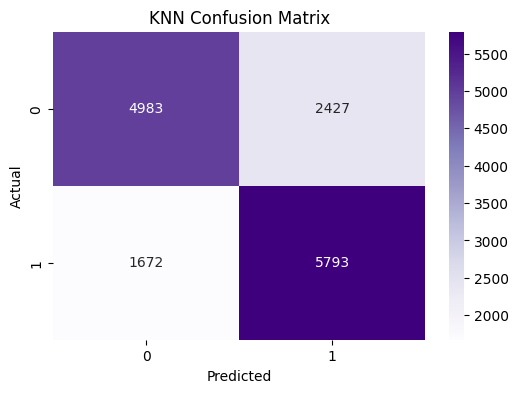

In [30]:
# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_test_pred_knn)

plt.figure(figsize=(6,4))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Purples", cbar=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.show()

In [31]:

# --------- Naive Bayes MODEL ---------
nb_model = MultinomialNB()

# Model training
nb_model.fit(X_train, y_train)

# Prediction based on training and testing
y_train_pred_nb = nb_model.predict(X_train)
y_test_pred_nb  = nb_model.predict(X_test)

# Accuracy calculation
train_acc_nb = accuracy_score(y_train, y_train_pred_nb)
test_acc_nb  = accuracy_score(y_test,  y_test_pred_nb)

print(f"Naive Bayes Train Accuracy : {train_acc_nb:.3%}")
print(f"Naive Bayes Test  Accuracy : {test_acc_nb:.3%}")



Naive Bayes Train Accuracy : 85.631%
Naive Bayes Test  Accuracy : 85.029%


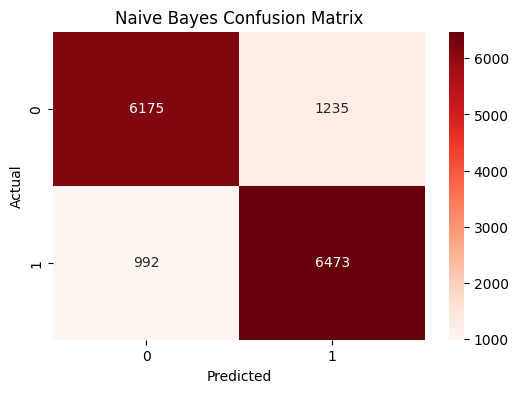

In [32]:
# Confusion Matrix
cm_nb = confusion_matrix(y_test, y_test_pred_nb)

plt.figure(figsize=(6,4))
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Reds", cbar=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")
plt.show()
